In [1]:
from ml_enhance import load_hpc_result, compare
from ml_enhance import CorrelationFilter
from ml_enhance import FeatureImportance
from sklearn.base import BaseEstimator
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
from brokenaxes import brokenaxes
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

In [2]:
def combine_dfs(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    r2_df = pd.concat([df[["name", "test_r2"]] for df in dfs])

    r2_df["group"] = r2_df["name"].str.extract(r"^(HuberReg|KRR|RF|chemprop)")
    r2_df["variant"] = r2_df["name"].str.extract(r"_(topo\+QM|topo)")

    r2_df["variant"] = r2_df["variant"].replace({
        "topo": "Topo",
        "topo+QM": "Topo+QM"
    })

    return r2_df

In [3]:
def plot_performance(r2_df: pd.DataFrame) -> None:
    order = (
        r2_df.groupby("group")["test_r2"]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    palette = {
        "Topo": "lightgray",
        "Topo+QM": "tab:blue"
    }

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        data=r2_df,
        y="test_r2",
        x="group",
        order=order,
        palette=palette,
        hue="variant",
        width=0.6,
        fliersize=0
    )

    sns.pointplot(
        data=r2_df,
        y="test_r2",
        x="group",
        hue="variant",
        palette={"Topo": "tab:red", "Topo+QM": "tab:red"},
        order=order,
        dodge=0.3,
        linestyles="None",
        color="tab:red",
        markers="D",
        alpha=0.6
    )

    sns.stripplot(data=r2_df, x="group", y="test_r2", hue="variant", dodge=True, palette="dark:black", alpha=0.4)

    strip_handle = mlines.Line2D(
        [], [],
        color="black",
        marker="o",
        linestyle="None",
        markersize=6,
        alpha=0.4,
        label="Individual scores"
    )

    point_handle = mlines.Line2D(
        [], [],
        color="tab:red",
        alpha=0.6,
        marker="D",
        linestyle="None",
        markersize=8,
        label="Mean ± SD"
    )

    legend_elements = [
        Patch(facecolor="tab:blue", edgecolor="black", label="QM + Topology"),
        Patch(facecolor="lightgray", edgecolor="black", label="Topology"),
    ]

    sns.despine(trim=False, left=False)

    plt.legend(handles=legend_elements+[point_handle, strip_handle], loc="lower left", frameon=False, fontsize=12)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("")
    plt.ylabel(r"$R^2$ score", fontsize=16)
    # plt.title("Model performance comparison", fontsize=16)
    plt.ylim(0.74, 0.9)

In [4]:
def dumbbell_plot(df):
    summary = df.groupby(["group", "variant"])["test_r2"].agg(["mean", "std"]).reset_index()

    group_means = summary.groupby("group")["mean"].mean().sort_values(ascending=True)
    groups = group_means.index.tolist()
     
    variants = ["Topo", "Topo+QM"]
    colors   = {"Topo": "grey", "Topo+QM": "tab:blue"}
    markers  = {"Topo": "s",    "Topo+QM": "o"}
    labels = {"Topo": "Topolgy",    "Topo+QM": "Topology\n+QM"}

    fig = plt.figure(figsize=(12, 5))
    bax = brokenaxes(xlims=((0.695, 0.715), (0.780, 0.900)), wspace=0.08, fig=fig)

    y_positions = {g: i for i, g in enumerate(groups)}
    jitter = 0.08

    for group in groups:
        y = y_positions[group]

        means = {
            v: summary.loc[(summary["group"] == group) & (summary["variant"] == v), "mean"].values[0]
            for v in variants
        }

    
        bax.plot([means["Topo"], means["Topo+QM"]], [y, y],
                color="lightgrey", linewidth=2, zorder=1)

        
        delta = means["Topo+QM"] - means["Topo"]
        mid_x = (means["Topo"] + means["Topo+QM"]) / 2
        bax.axs[1].text(mid_x, y + 0.18, r"$\Delta$R$^2$"+f"={delta:+.3f}",
                        ha="center", va="bottom", fontsize=14, color="black")

        for variant in variants:
            subset = df[(df["group"] == group) & (df["variant"] == variant)]["test_r2"].values
            m = means[variant]
            s = summary.loc[(summary["group"] == group) & (summary["variant"] == variant), "std"].values[0]

            jittered_y = y + np.random.uniform(-jitter, jitter, size=len(subset))
            bax.scatter(subset, jittered_y, color=colors[variant], marker=markers[variant],
                        alpha=0.3, s=20, zorder=2)

            bax.scatter(m, y, color=colors[variant], marker=markers[variant],
                        s=120, zorder=4, edgecolors="white", linewidths=1.2)
            bax.errorbar(m, y, xerr=s, fmt="none", color=colors[variant],
                        capsize=5, capthick=1.5, linewidth=1.5, zorder=3)

    bax.axs[0].set_yticks(list(y_positions.values()))
    bax.axs[0].set_yticklabels(list(y_positions.keys()), fontsize=16)

    bax.axs[0].tick_params(axis="x", labelsize=16)
    bax.axs[1].tick_params(axis="x", labelsize=16)


    handles = [mlines.Line2D([], [], color=colors[v], marker=markers[v],
            linestyle="None", markersize=9, label=labels[v]) for v in variants]

    bax.axs[0].legend(handles=handles, frameon=False, loc="upper center", fontsize=14, bbox_to_anchor=(0.5, 1), handletextpad=0.1)

    bax.set_xlabel(r"Test R$^2$", fontsize=18, labelpad=30)

In [5]:
def process_FI_data(fi_data: pd.DataFrame) -> dict[int, pd.Series]:
    groups = fi_data[["fold_id", "feature", "r2_mean"]]
    return {
        int(fold_id): df.set_index("feature")["r2_mean"]
        for fold_id, df in groups.groupby("fold_id")
    }

In [6]:
from math import floor

n_tot = 8759 # 8763 before rerun
n_train = floor(n_tot * (4/5))
n_test = n_tot - n_train

### Unfiltered feature set

In [7]:
HuberReg_combo_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_combo_rerun_results.pkl"), "HuberReg_topo+QM")
HuberReg_topo_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_topo_rerun_results.pkl"), "HuberReg_topo")

In [8]:
KRR_combo_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_rerun_results.pkl"), "KRR_topo+QM")
KRR_topo_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_rerun_results.pkl"), "KRR_topo")

In [9]:
RF_topo_df = load_hpc_result(Path("../data/RF_results/1_RF_topo_rerun_results.pkl"), "RF_topo")
RF_combo_df = load_hpc_result(Path("../data/RF_results/1_RF_combo_rerun_results.pkl"), "RF_topo+QM")

In [10]:
df_w_atom = pd.read_csv(r"..\data\chemprop_results\3_chemprop_atom_feat_rerun_results.json")
df_w_atom["name"] = "chemprop_topo+QM"
df_w_atom = df_w_atom.rename({"r2_test": "test_r2"}, axis=1)
df_w_atom = df_w_atom.rename({"mse_test": "test_MSE"}, axis=1)
df_wo_atom = pd.read_csv(r"..\data\chemprop_results\3_chemprop_no_added_rerun_results.json")
df_wo_atom["name"] = "chemprop_topo"
df_wo_atom = df_wo_atom.rename({"r2_test": "test_r2"}, axis=1)
df_wo_atom = df_wo_atom.rename({"mse_test": "test_MSE"}, axis=1)

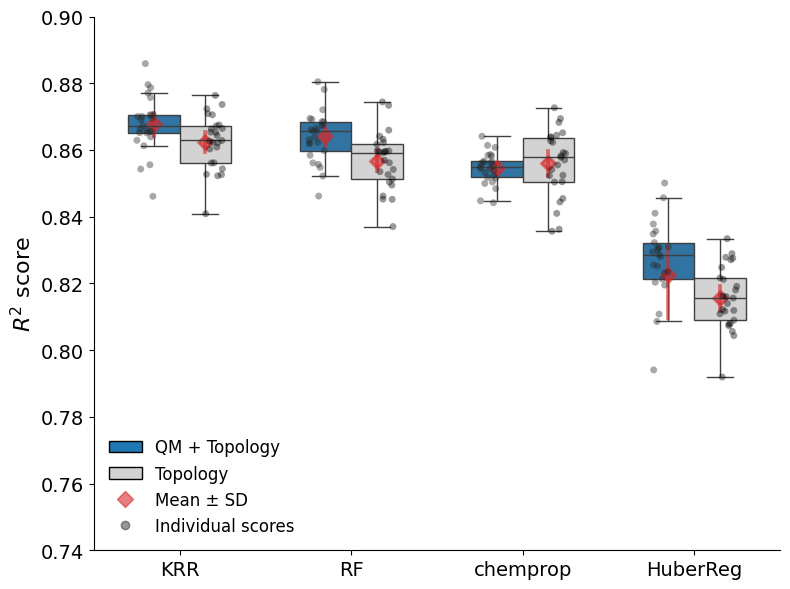

In [11]:
r2_df = combine_dfs([
        HuberReg_combo_df,
        HuberReg_topo_df,
        KRR_combo_df,
        KRR_topo_df,
        RF_topo_df,
        RF_combo_df,
        df_w_atom,
        df_wo_atom
    ])

plot_performance(r2_df)
plt.tight_layout()
plt.show()

In [12]:
r2_df

,name,test_r2,group,variant
0,HuberReg_topo+QM,0.825513,HuberReg,Topo+QM
10,HuberReg_topo+QM,0.841027,HuberReg,Topo+QM
11,HuberReg_topo+QM,0.830033,HuberReg,Topo+QM
12,HuberReg_topo+QM,0.830765,HuberReg,Topo+QM
13,HuberReg_topo+QM,0.827969,HuberReg,Topo+QM
...,...,...,...,...
20,chemprop_topo,0.864423,chemprop,Topo
21,chemprop_topo,0.844409,chemprop,Topo
22,chemprop_topo,0.872645,chemprop,Topo
23,chemprop_topo,0.840988,chemprop,Topo


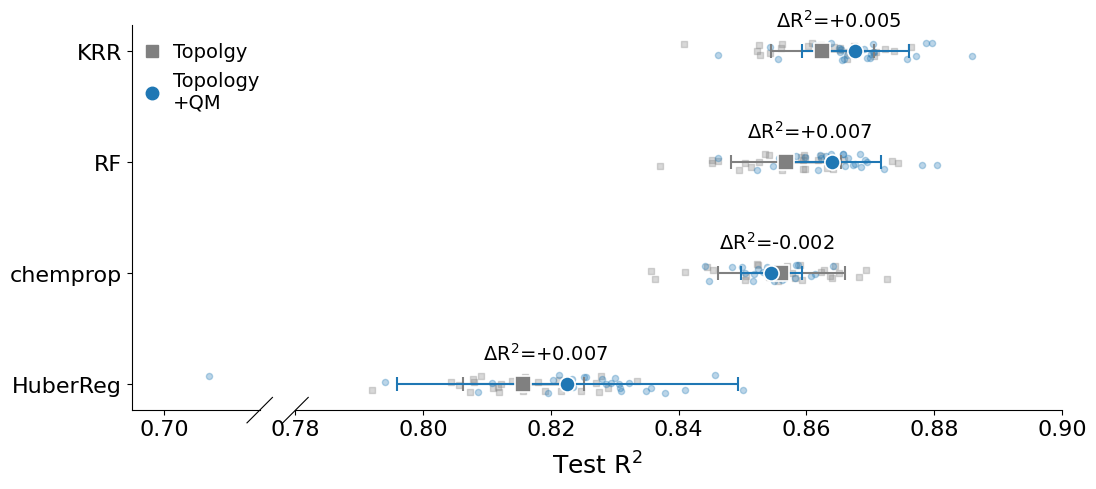

In [13]:
dumbbell_plot(r2_df)
plt.show()

In [14]:
compare(df_w_atom, df_wo_atom, n_train=n_train, n_test=n_test, train_score=False)

chemprop_topo+QM mean r2: 0.854503014087677
chemprop_topo mean r2: 0.8560618686676026
Mean improvement: -0.0015588545799255372
T-test p-value: 0.4377344330193975 -> not statistically significant
Wilcoxon p-value: 0.457846462726593 -> not statistically significant


chemprop_topo+QM mean MSE: 0.14548354804515834
chemprop_topo mean MSE: 0.1438478726148605
Mean improvement: 0.0016356754302978517
T-test p-value: 0.4164894647985138 -> not statistically significant
Wilcoxon p-value: 0.4107651710510254 -> not statistically significant




In [15]:
compare(HuberReg_combo_df, HuberReg_topo_df, n_train=n_train, n_test=n_test)

HuberReg_topo+QM mean r2: 0.8225844602530548 (Train: 0.845893321631955)
HuberReg_topo mean r2: 0.815675707766128 (Train: 0.8275717079136661)
Mean improvement: 0.006908752486926999
T-test p-value: 0.1941960615751519 -> not statistically significant
Wilcoxon p-value: 0.0001398921012878418 -> statistically significant


HuberReg_topo+QM mean MSE: 0.9442052351843386 (Train: 0.8211122659332841)
HuberReg_topo mean MSE: 0.98119024673991 (Train: 0.9187565081836431)
Mean improvement: -0.03698501155557135
T-test p-value: 0.18726913865624661 -> not statistically significant
Wilcoxon p-value: 0.0001398921012878418 -> statistically significant




In [16]:
compare(KRR_combo_df, KRR_topo_df, n_train=n_train, n_test=n_test)

KRR_topo+QM mean r2: 0.8676719915058656 (Train: 0.9669099660169083)
KRR_topo mean r2: 0.8624876250542962 (Train: 0.9453246568437613)
Mean improvement: 0.005184366451569362
T-test p-value: 1.8567662483093272e-06 -> statistically significant
Wilcoxon p-value: 8.344650268554688e-07 -> statistically significant


KRR_topo+QM mean MSE: 0.7042758428775809 (Train: 0.17631152529205582)
KRR_topo mean MSE: 0.7318278277516194 (Train: 0.2913248169761584)
Mean improvement: -0.027551984874038555
T-test p-value: 1.7482195566742575e-06 -> statistically significant
Wilcoxon p-value: 8.344650268554688e-07 -> statistically significant




In [17]:
compare(RF_combo_df, RF_topo_df, n_train=n_train, n_test=n_test)

RF_topo+QM mean r2: 0.8640537758779351 (Train: 0.9616906844721747)
RF_topo mean r2: 0.8568107637500278 (Train: 0.9556521774044117)
Mean improvement: 0.0072430121279071355
T-test p-value: 1.4210854715202004e-14 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


RF_topo+QM mean MSE: 0.7234741997565944 (Train: 0.20411979404390249)
RF_topo mean MSE: 0.7618814454687651 (Train: 0.23629352500479672)
Mean improvement: -0.03840724571217073
T-test p-value: 3.9968028886505635e-15 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [94]:
huber_data = pd.read_csv(r"..\data\HuberReg_results\1_HuberReg_combo_rerun_PFI_results.csv")
huber_FI_dict = process_FI_data(huber_data)

huber_FI = FeatureImportance(HuberReg_combo_df, provided_FI=huber_FI_dict)
huber_fi_df = huber_FI.get_feature_importance(20, mode="full")



krr_data = pd.read_csv(r"..\data\KRR_results\1_KRR_combo_rerun_PFI_results.csv")
krr_FI_dict = process_FI_data(krr_data)

krr_FI = FeatureImportance(KRR_combo_df, provided_FI=krr_FI_dict)
krr_fi_df = krr_FI.get_feature_importance(20, mode="full")



# rf_data = pd.read_csv(r"..\data\RF_results\1_RF_combo_rerun_PFI_results.csv")
rf_data = pd.read_csv(r"..\data\RF_results\1_RF_combo_rerun_PFI_results.csv")
rf_FI_dict = process_FI_data(rf_data)

rf_FI = FeatureImportance(RF_combo_df, provided_FI=rf_FI_dict)
rf_fi_df = rf_FI.get_feature_importance(20, mode="full")

C:\Users\thibo\AppData\Local\Temp\ipykernel_16740\2822960524.py:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


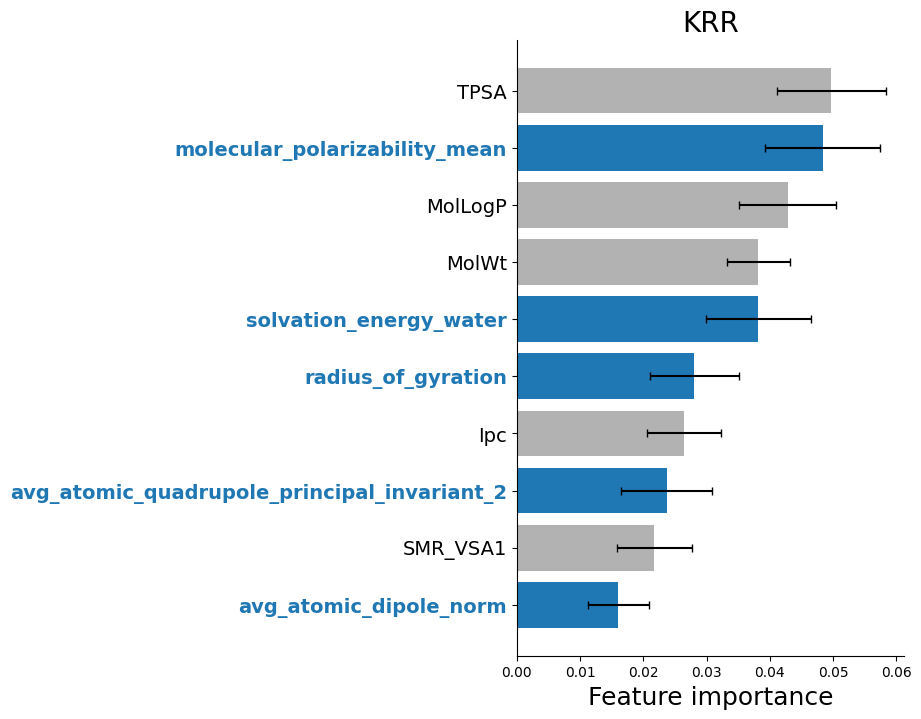

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8))
krr_FI.plot(ax, num_features=10, title="KRR")
plt.tight_layout()
# plt.savefig("KRR_FI.pdf", bbox_inches="tight", format="pdf")
plt.show()

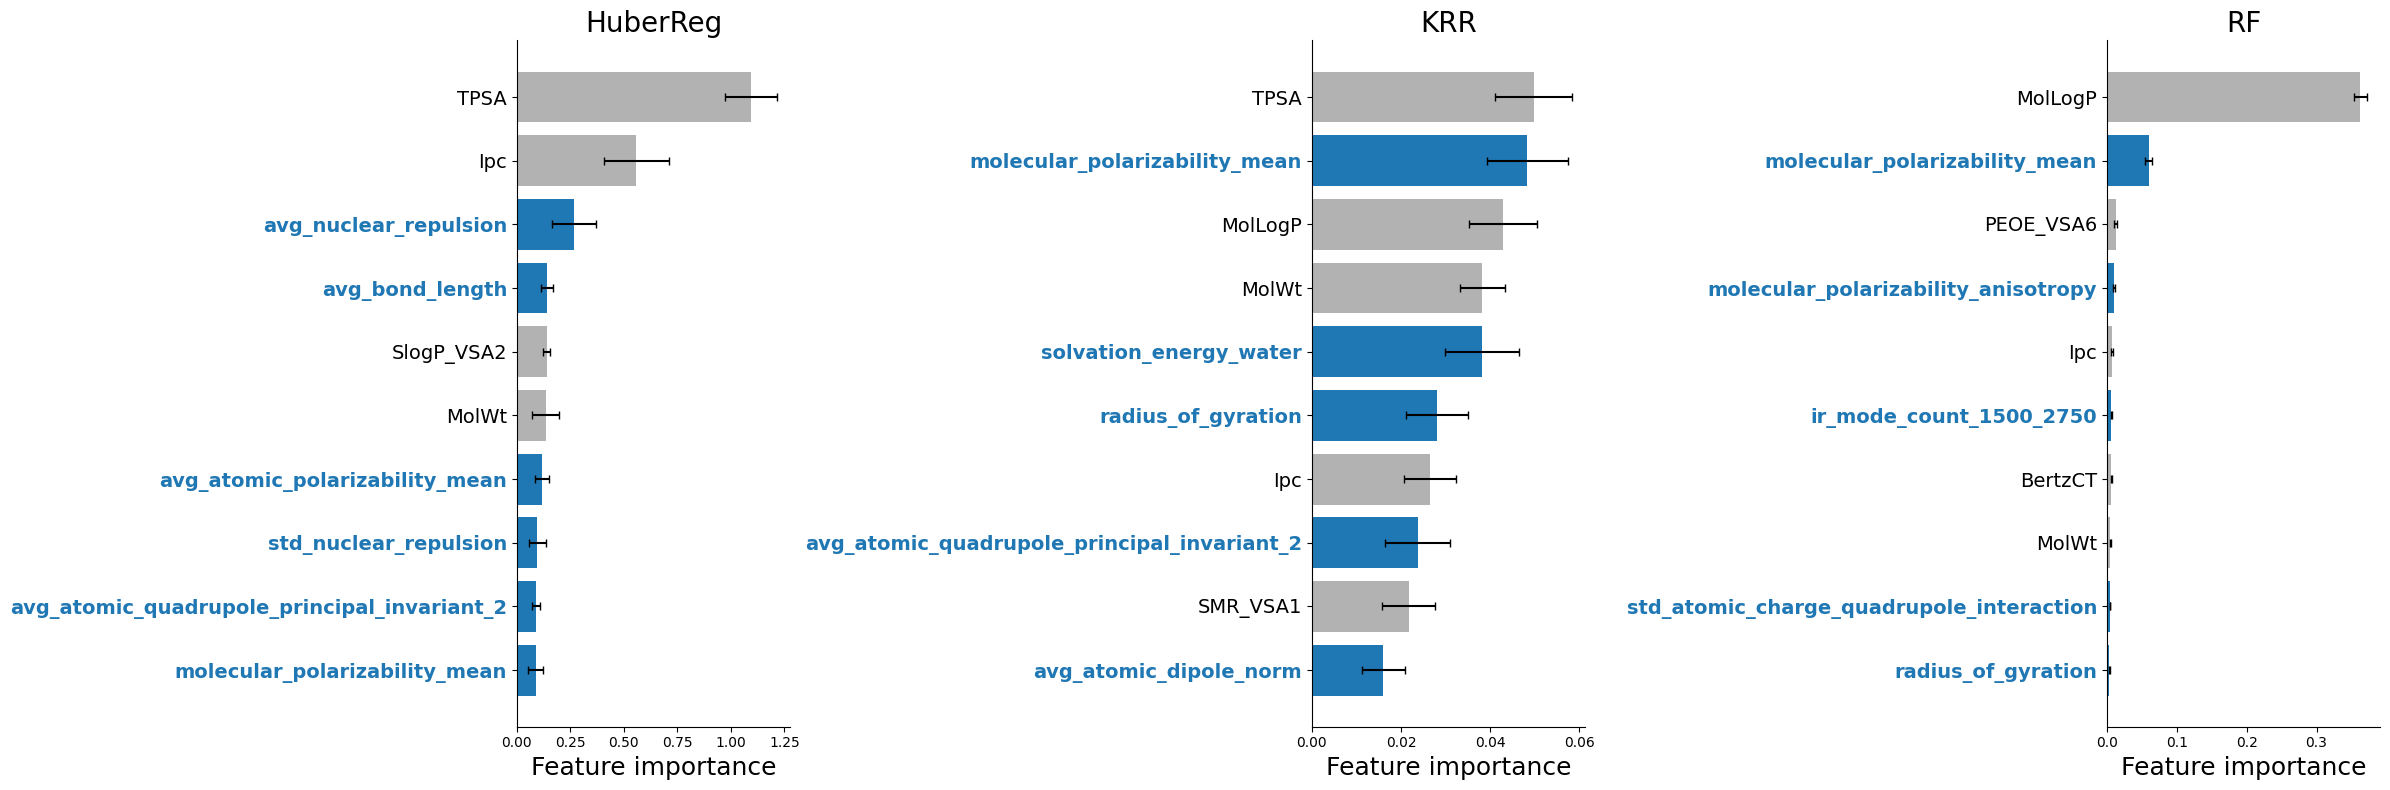

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

huber_FI.plot(ax1, num_features=10, title="HuberReg")
krr_FI.plot(ax2, num_features=10, title="KRR")
rf_FI.plot(ax3, num_features=10, title="RF")

plt.tight_layout()
# plt.savefig("FI_compare.pdf", dpi=300, format="pdf")
plt.show()

In [91]:
import re

[col for col in krr_fi_df["feature"] if re.search("partial_charge$|molecular_dipole", col)]

['molecular_dipole_norm',
 'min_partial_charge',
 'max_partial_charge',
 'std_partial_charge']

In [ ]:
huber_fi_df[huber_fi_df["feature"].isin(["molecular_dipole_norm", "min_partial_charge", "max_partial_charge", "std_partial_charge"])]

,feature,frequency,mean_importance,std_importance,score,std_score
17,std_partial_charge,1.0,0.025939,0.010454,0.025939,0.010454
86,min_partial_charge,1.0,0.003029,0.002241,0.003029,0.002241
122,max_partial_charge,1.0,0.001635,0.001513,0.001635,0.001513
166,molecular_dipole_norm,1.0,0.000748,0.000512,0.000748,0.000512


In [98]:
krr_fi_df[krr_fi_df["feature"].isin(["molecular_dipole_norm", "min_partial_charge", "max_partial_charge", "std_partial_charge"])]

,feature,frequency,mean_importance,std_importance,score,std_score
81,molecular_dipole_norm,1.0,0.002325,0.000859,0.002325,0.000859
125,min_partial_charge,1.0,0.001307,0.001357,0.001307,0.001357
147,max_partial_charge,1.0,0.001144,0.000567,0.001144,0.000567
152,std_partial_charge,1.0,0.001112,0.001424,0.001112,0.001424


In [99]:
rf_fi_df[rf_fi_df["feature"].isin(["molecular_dipole_norm", "min_partial_charge", "max_partial_charge", "std_partial_charge"])]

,feature,frequency,mean_importance,std_importance,score,std_score
18,max_partial_charge,1.0,0.001607,0.000248,0.001607,0.000248
22,std_partial_charge,1.0,0.001481,0.000298,0.001481,0.000298
45,min_partial_charge,1.0,0.000677,0.000115,0.000677,0.000115
53,molecular_dipole_norm,1.0,0.000540,0.000100,0.000540,0.000100


### Only relevant features

In [44]:
HuberReg_combo_relevant_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_combo_relevant_rerun_results.pkl"), "HuberReg_topo+QM_relevant")
HuberReg_topo_relevant_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_topo_relevant_rerun_results.pkl"), "HuberReg_topo_relevant")

In [45]:
KRR_topo_relevant_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_relevant_rerun_results.pkl"), "KRR_topo_relevant")
KRR_combo_relevant_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_relevant_rerun_results.pkl"), "KRR_topo+QM_relevant")

In [46]:
RF_topo_relevant_df = load_hpc_result(Path("../data/RF_results/1_RF_topo_relevant_rerun_results.pkl"), "RF_topo_relevant")
RF_combo_relevant_df = load_hpc_result(Path("../data/RF_results/1_RF_combo_relevant_rerun_results.pkl"), "RF_topo+QM_relevant")

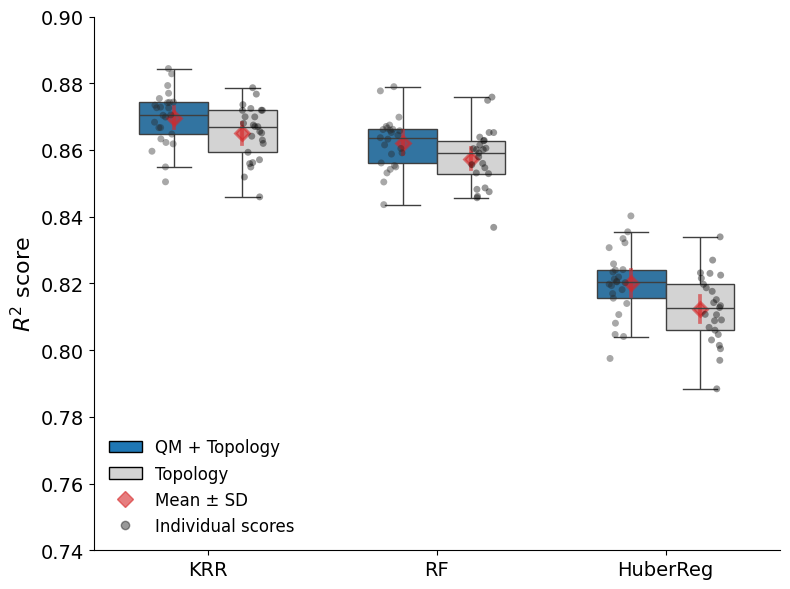

In [47]:
r2_df_relevant = combine_dfs([
        HuberReg_combo_relevant_df,
        HuberReg_topo_relevant_df,
        KRR_combo_relevant_df,
        KRR_topo_relevant_df,
        RF_topo_relevant_df,
        RF_combo_relevant_df
    ])

plot_performance(r2_df_relevant)
plt.tight_layout()
plt.show()

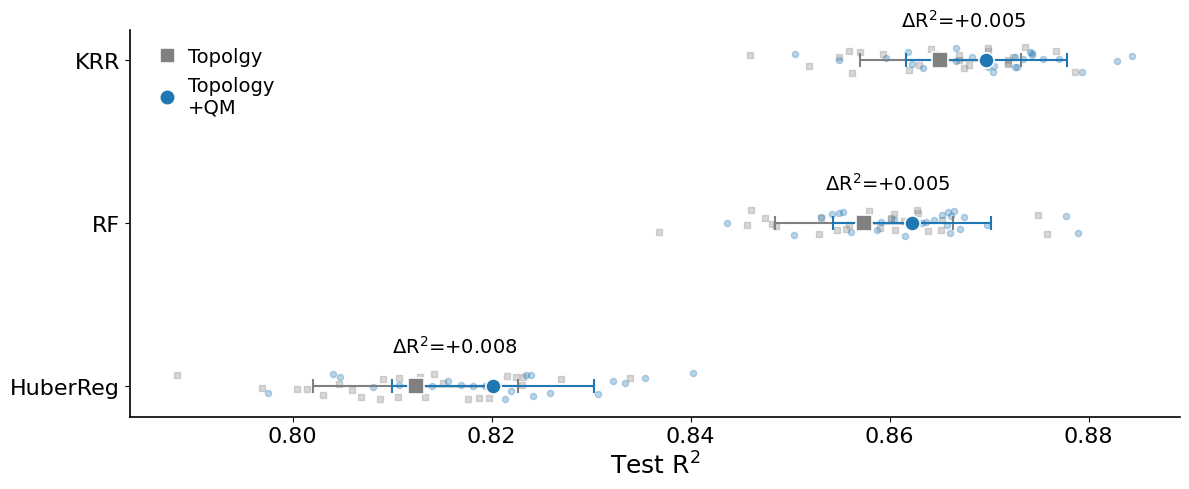

In [76]:
summary = r2_df_relevant.groupby(["group", "variant"])["test_r2"].agg(["mean", "std"]).reset_index()

group_means = summary.groupby("group")["mean"].mean().sort_values(ascending=True)
groups = group_means.index.tolist()

variants = ["Topo", "Topo+QM"]
colors   = {"Topo": "grey", "Topo+QM": "tab:blue"}
markers  = {"Topo": "s",    "Topo+QM": "o"}
labels   = {"Topo": "Topolgy", "Topo+QM": "Topology\n+QM"}

fig, ax = plt.subplots(figsize=(12, 5))

y_positions = {g: i for i, g in enumerate(groups)}
jitter = 0.08

for group in groups:
    y = y_positions[group]

    means = {
        v: summary.loc[
            (summary["group"] == group) & (summary["variant"] == v), "mean"
        ].values[0]
        for v in variants
    }

    ax.plot([means["Topo"], means["Topo+QM"]], [y, y],
            color="lightgrey", linewidth=2, zorder=1)

    delta = means["Topo+QM"] - means["Topo"]
    mid_x = (means["Topo"] + means["Topo+QM"]) / 2
    ax.text(mid_x, y + 0.18, r"$\Delta$R$^2$" + f"={delta:+.3f}",
            ha="center", va="bottom", fontsize=14)

    for variant in variants:
        subset = r2_df_relevant[
            (r2_df_relevant["group"] == group) &
            (r2_df_relevant["variant"] == variant)
        ]["test_r2"].values

        m = means[variant]
        s = summary.loc[
            (summary["group"] == group) & (summary["variant"] == variant), "std"
        ].values[0]

        jittered_y = y + np.random.uniform(-jitter, jitter, size=len(subset))

        ax.scatter(subset, jittered_y,
                   color=colors[variant],
                   marker=markers[variant],
                   alpha=0.3, s=20, zorder=2)

        ax.scatter(m, y,
                   color=colors[variant],
                   marker=markers[variant],
                   s=120, zorder=4,
                   edgecolors="white", linewidths=1.2)

        ax.errorbar(m, y, xerr=s,
                    fmt="none",
                    color=colors[variant],
                    capsize=5, capthick=1.5,
                    linewidth=1.5, zorder=3)

# y-axis
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()), fontsize=16)

# x-axis
ax.tick_params(axis="x", labelsize=16)

# 🔥 styling to mimic brokenaxes look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# optional: soften remaining spines
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# optional: remove grid if present
ax.grid(False)

# legend
handles = [
    mlines.Line2D([], [], color=colors[v], marker=markers[v],
                  linestyle="None", markersize=9, label=labels[v])
    for v in variants
]

ax.legend(handles=handles, frameon=False,
          loc="upper left", fontsize=14, handletextpad=0.1)

ax.set_xlabel(r"Test R$^2$", fontsize=18)

plt.tight_layout()

In [48]:
result = (
    r2_df_relevant
    .groupby("name")["test_r2"]
    .agg(["mean", "std"])
    .reset_index()
)
result

,name,mean,std
0,HuberReg_topo+QM_relevant,0.820103,0.010143
1,HuberReg_topo_relevant,0.812379,0.010311
2,KRR_topo+QM_relevant,0.869713,0.008076
3,KRR_topo_relevant,0.865087,0.008102
4,RF_topo+QM_relevant,0.862224,0.007954
5,RF_topo_relevant,0.857412,0.008950


In [49]:
compare(HuberReg_combo_relevant_df, HuberReg_topo_relevant_df, n_train=n_train, n_test=n_test)

HuberReg_topo+QM_relevant mean r2: 0.8201028487096464 (Train: 0.8338952248053524)
HuberReg_topo_relevant mean r2: 0.8123793979340108 (Train: 0.8244105681334191)
Mean improvement: 0.007723450775635525
T-test p-value: 5.651523693472882e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


HuberReg_topo+QM_relevant mean MSE: 0.9577180716971871 (Train: 0.8850710883764441)
HuberReg_topo_relevant mean MSE: 0.9988044718061017 (Train: 0.935602851234462)
Mean improvement: -0.041086400108914525
T-test p-value: 5.7772897577024196e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [50]:
compare(KRR_combo_relevant_df, KRR_topo_relevant_df, n_train=n_train, n_test=n_test)

KRR_topo+QM_relevant mean r2: 0.8697128448843547 (Train: 0.9601237952670004)
KRR_topo_relevant mean r2: 0.865087360456852 (Train: 0.9457995298194344)
Mean improvement: 0.004625484427502862
T-test p-value: 1.0527373173196963e-07 -> statistically significant
Wilcoxon p-value: 1.7881393432617188e-07 -> statistically significant


KRR_topo+QM_relevant mean MSE: 0.6934070625637219 (Train: 0.21246866175530305)
KRR_topo_relevant mean MSE: 0.7179580102923815 (Train: 0.2887941649940877)
Mean improvement: -0.024550947728659553
T-test p-value: 8.457258982019766e-08 -> statistically significant
Wilcoxon p-value: 1.7881393432617188e-07 -> statistically significant




In [51]:
compare(RF_combo_relevant_df, RF_topo_relevant_df, n_train=n_train, n_test=n_test)

RF_topo+QM_relevant mean r2: 0.8622241019840726 (Train: 0.9602437584859013)
RF_topo_relevant mean r2: 0.857411931665514 (Train: 0.9561229136978266)
Mean improvement: 0.004812170318558762
T-test p-value: 4.044742318853878e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


RF_topo+QM_relevant mean MSE: 0.7331211156827163 (Train: 0.2118294300083085)
RF_topo_relevant mean MSE: 0.7586832094061955 (Train: 0.233784304719093)
Mean improvement: -0.025562093723479385
T-test p-value: 3.615707733217732e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [52]:
huber_data = pd.read_csv(r"..\data\HuberReg_results\1_HuberReg_combo_relevant_rerun_PFI_results.csv")
huber_FI_dict = process_FI_data(huber_data)

huber_FI = FeatureImportance(HuberReg_combo_relevant_df, provided_FI=huber_FI_dict)
huber_fi_df = huber_FI.get_feature_importance(20)



krr_data = pd.read_csv(r"..\data\KRR_results\1_KRR_combo_relevant_rerun_PFI_results.csv")
krr_FI_dict = process_FI_data(krr_data)

krr_FI = FeatureImportance(KRR_combo_relevant_df, provided_FI=krr_FI_dict)
krr_fi_df = krr_FI.get_feature_importance(20)



rf_data = pd.read_csv(r"..\data\RF_results\1_RF_combo_relevant_PFI_results.csv")
rf_FI_dict = process_FI_data(rf_data)

rf_FI = FeatureImportance(RF_combo_relevant_df, provided_FI=rf_FI_dict)
rf_fi_df = rf_FI.get_feature_importance(20)

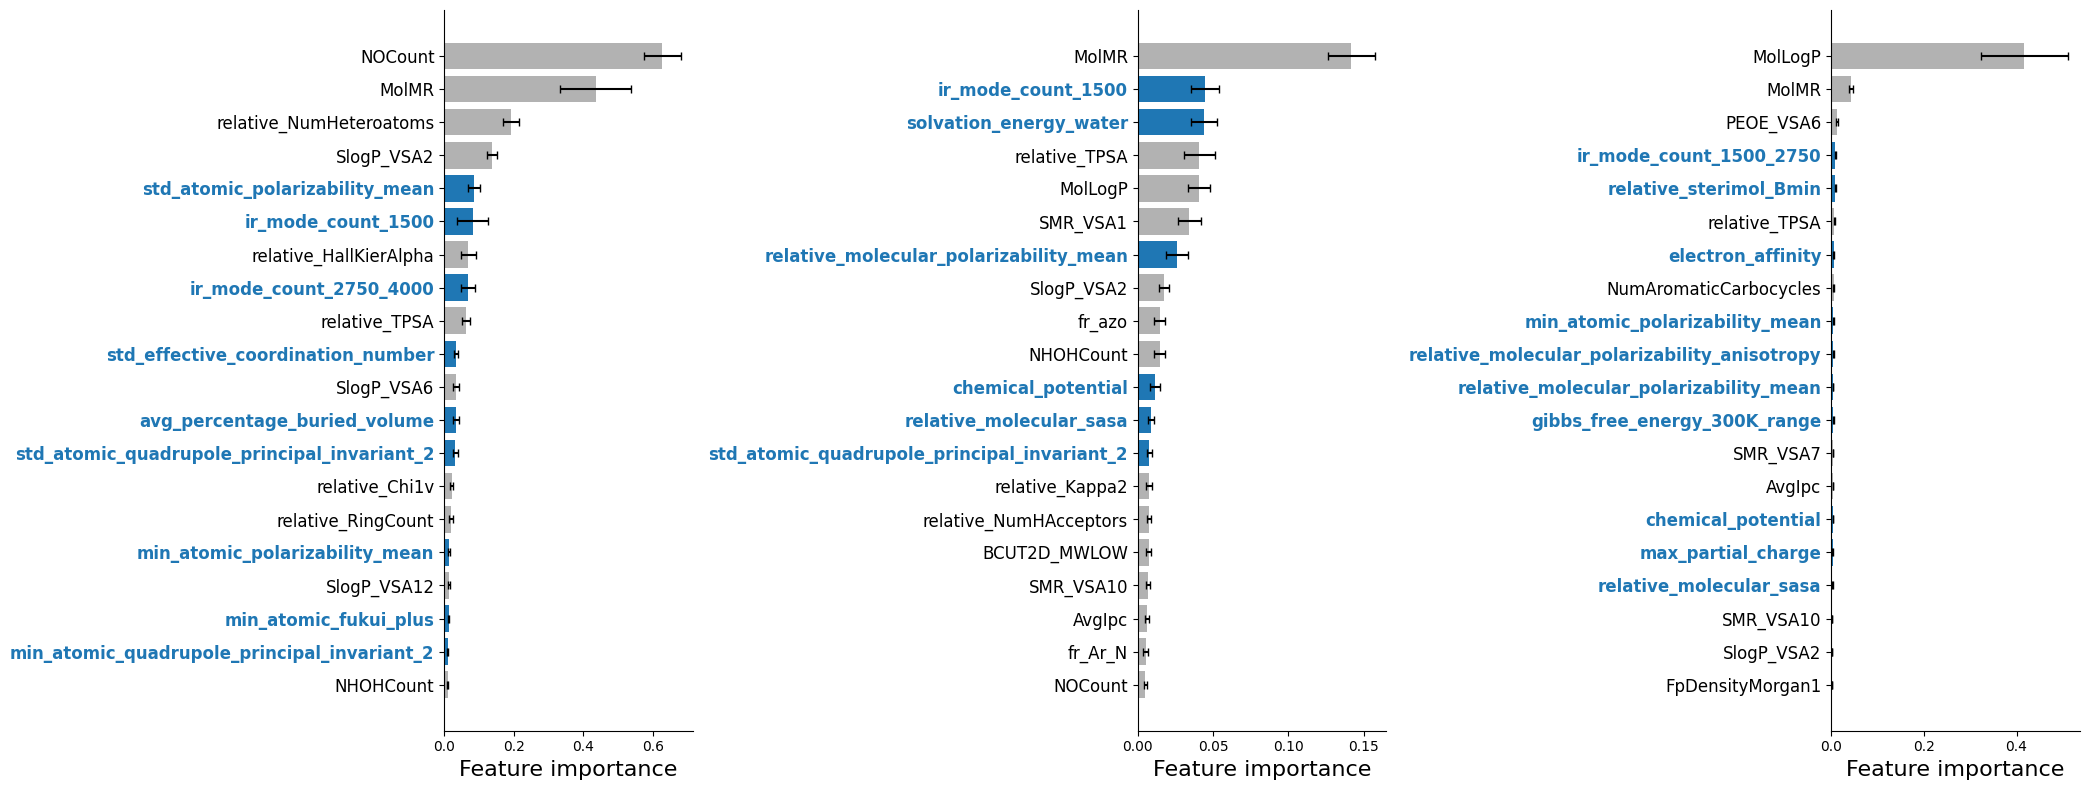

In [53]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 8))

huber_FI.plot(ax1)
krr_FI.plot(ax2)
rf_FI.plot(ax3)

plt.tight_layout()
plt.show()

### Only relevant features, no normalization

In [54]:
HuberReg_combo_relevant_no_norm_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_combo_relevant_no_norm_rerun_results.pkl"), "HuberReg_topo+QM_relevant_no_norm")
HuberReg_topo_relevant_no_norm_df = load_hpc_result(Path("../data/HuberReg_results/1_HuberReg_topo_relevant_no_norm_rerun_results.pkl"), "HuberReg_topo_relevant_no_norm")

In [55]:
KRR_topo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_relevant_no_norm_rerun_results.pkl"), "KRR_topo_relevant_no_norm")
KRR_combo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_relevant_no_norm_rerun_results.pkl"), "KRR_topo+QM_relevant_no_norm")

In [56]:
RF_topo_relevant_no_norm_df = load_hpc_result(Path("../data/RF_results/1_RF_topo_relevant_no_norm_rerun_results.pkl"), "RF_topo_relevant_no_norm")
RF_combo_relevant_no_norm_df = load_hpc_result(Path("../data/RF_results/1_RF_combo_relevant_no_norm_rerun_results.pkl"), "RF_topo+QM_relevant_no_norm")

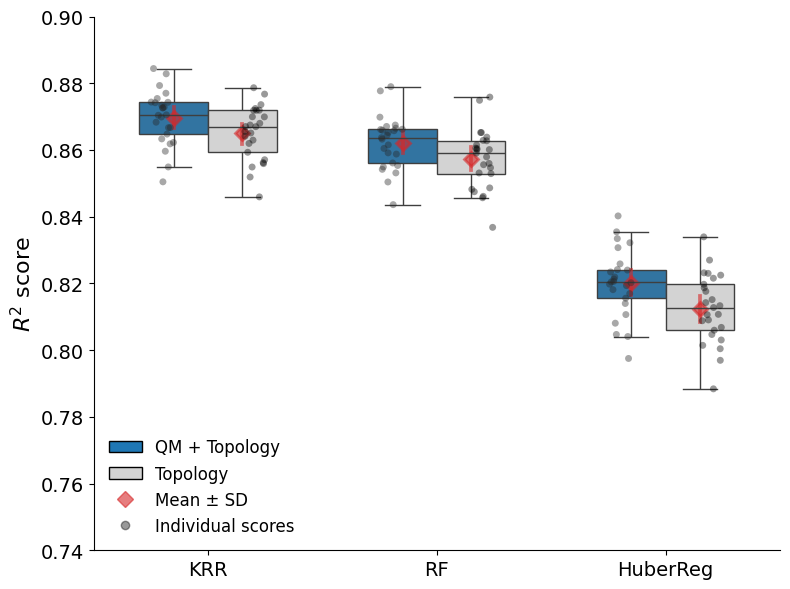

In [57]:
r2_df_relevant = combine_dfs([
        HuberReg_combo_relevant_df,
        HuberReg_topo_relevant_df,
        KRR_combo_relevant_df,
        KRR_topo_relevant_df,
        RF_topo_relevant_df,
        RF_combo_relevant_df
    ])

plot_performance(r2_df_relevant)
plt.tight_layout()
plt.show()

In [58]:
compare(HuberReg_combo_relevant_no_norm_df, HuberReg_topo_relevant_no_norm_df, n_train=n_train, n_test=n_test)

HuberReg_topo+QM_relevant_no_norm mean r2: 0.8219259696325172 (Train: 0.835579938043398)
HuberReg_topo_relevant_no_norm mean r2: 0.8128012132257473 (Train: 0.8246324412032408)
Mean improvement: 0.009124756406769765
T-test p-value: 6.8833827526759706e-15 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


HuberReg_topo+QM_relevant_no_norm mean MSE: 0.9479966184188947 (Train: 0.8760936227215051)
HuberReg_topo_relevant_no_norm mean MSE: 0.9964852384967581 (Train: 0.9344164527831574)
Mean improvement: -0.04848862007786328
T-test p-value: 4.440892098500626e-15 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [59]:
compare(KRR_combo_relevant_no_norm_df, KRR_topo_relevant_no_norm_df, n_train=n_train, n_test=n_test)

KRR_topo+QM_relevant_no_norm mean r2: 0.8693165770325004 (Train: 0.9593170185344971)
KRR_topo_relevant_no_norm mean r2: 0.8636338293662482 (Train: 0.9439601221982745)
Mean improvement: 0.0056827476662522705
T-test p-value: 2.423612421864618e-10 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


KRR_topo+QM_relevant_no_norm mean MSE: 0.6954926469208279 (Train: 0.2167662374242554)
KRR_topo_relevant_no_norm mean MSE: 0.7257431193875645 (Train: 0.29859550582793853)
Mean improvement: -0.030250472466736813
T-test p-value: 2.3713919716783494e-10 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [60]:
compare(RF_combo_relevant_no_norm_df, RF_topo_relevant_no_norm_df, n_train=n_train, n_test=n_test)

RF_topo+QM_relevant_no_norm mean r2: 0.8623940473112027 (Train: 0.960016285406785)
RF_topo_relevant_no_norm mean r2: 0.8571279890731767 (Train: 0.955384763672352)
Mean improvement: 0.005266058238026159
T-test p-value: 3.571742901442576e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


RF_topo+QM_relevant_no_norm mean MSE: 0.7322817747286585 (Train: 0.21304094436631307)
RF_topo_relevant_no_norm mean MSE: 0.7601863280610576 (Train: 0.23771712213230964)
Mean improvement: -0.027904553332399093
T-test p-value: 2.394506815051045e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [65]:
huber_data = pd.read_csv(r"..\data\HuberReg_results\1_HuberReg_combo_relevant_no_norm_rerun_PFI_results.csv")
huber_FI_dict = process_FI_data(huber_data)

huber_FI = FeatureImportance(HuberReg_combo_relevant_no_norm_df, provided_FI=huber_FI_dict)
huber_fi_df = huber_FI.get_feature_importance(20)



krr_data = pd.read_csv(r"..\data\KRR_results\1_KRR_combo_relevant_no_norm_rerun_PFI_results.csv")
krr_FI_dict = process_FI_data(krr_data)

krr_FI = FeatureImportance(KRR_combo_relevant_no_norm_df, provided_FI=krr_FI_dict)
krr_fi_df = krr_FI.get_feature_importance(20)



rf_data = pd.read_csv(r"..\data\RF_results\1_RF_combo_relevant_no_norm_rerun_PFI_results.csv")
rf_FI_dict = process_FI_data(rf_data)

rf_FI = FeatureImportance(RF_combo_relevant_no_norm_df, provided_FI=rf_FI_dict)
rf_fi_df = rf_FI.get_feature_importance(20)

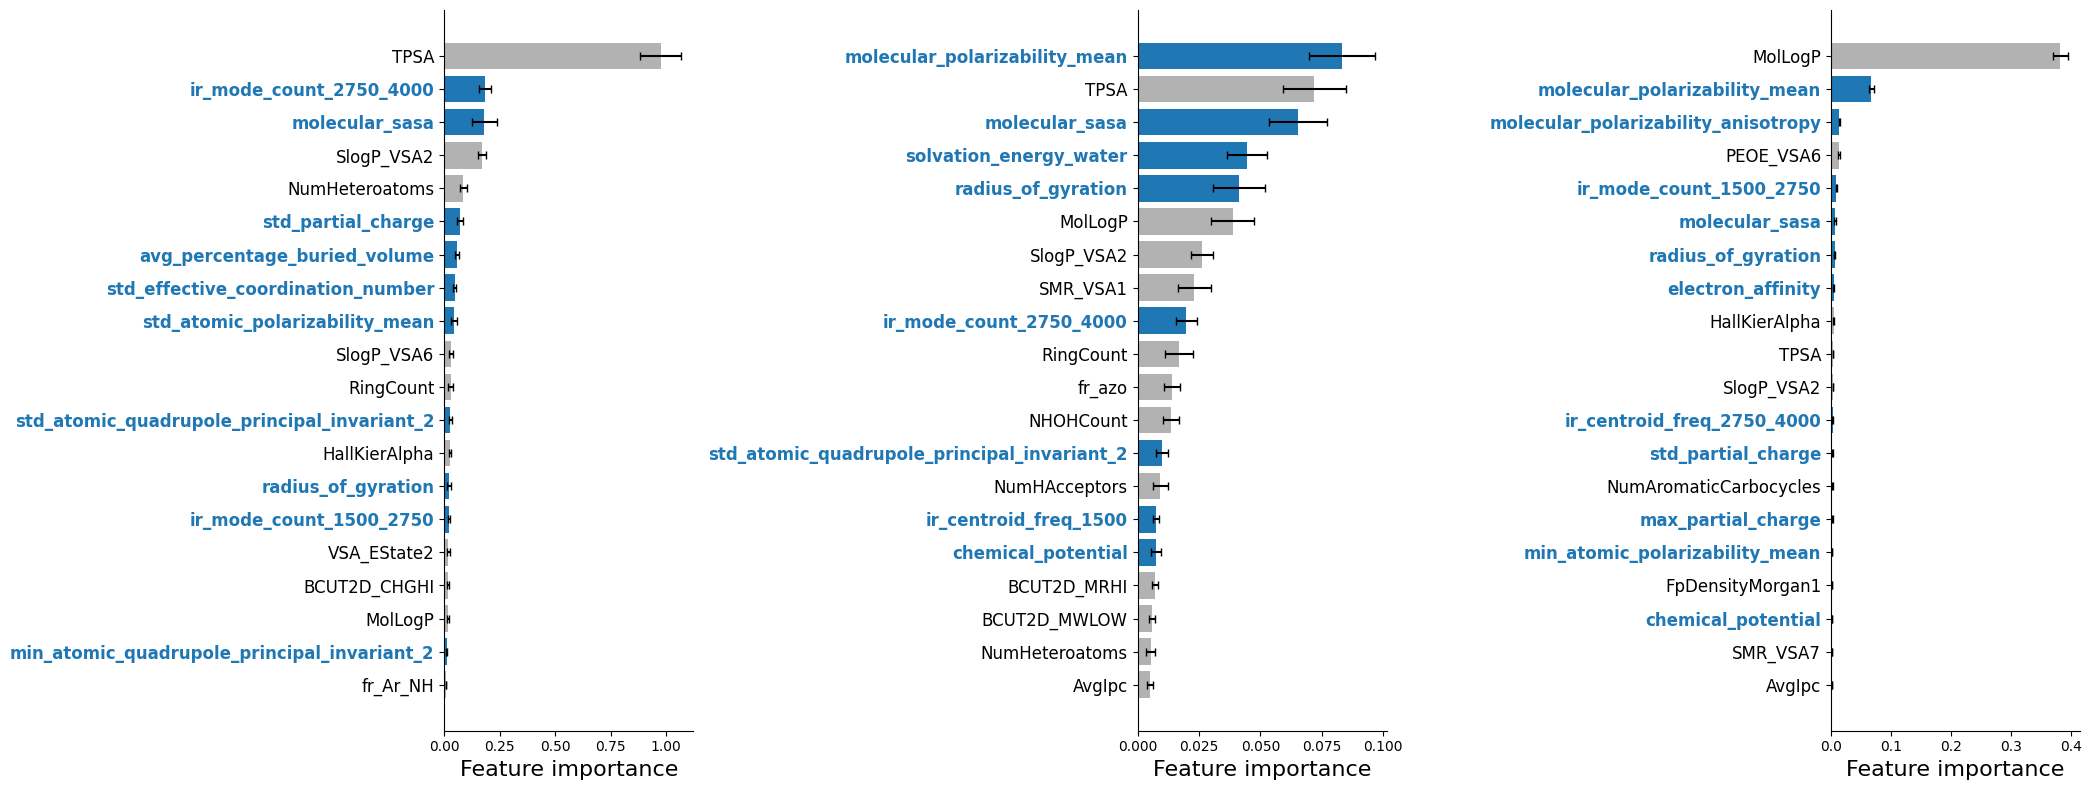

In [66]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 8))

huber_FI.plot(ax1)
krr_FI.plot(ax2)
rf_FI.plot(ax3)

plt.tight_layout()
plt.show()